In [1]:
# LAB 04A 
# TAREFA 10

In [2]:
import pandas as pd
dataset = pd.read_csv('./diabetes.txt',delimiter='\t')

In [3]:
dataset.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [4]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
SEX,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
BMI,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
BP,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
S1,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
S2,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
S3,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
S4,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
S5,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
S6,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


In [5]:
# Pergunta 01: Qual o valor médio da variável independente?
# Pergunta 02: Qual o desvio padrão da variável independente?
# Pergunta 03: Considerando-se a métrica erro quadrático qual seria o valor médio inferior
# aceitável para um modelo inteligente?

In [6]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [7]:
from sklearn.model_selection import train_test_split
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 110)

In [8]:
# Modelo de Treinamento Solicitado neste exercício
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_treinamento, y_treinamento)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


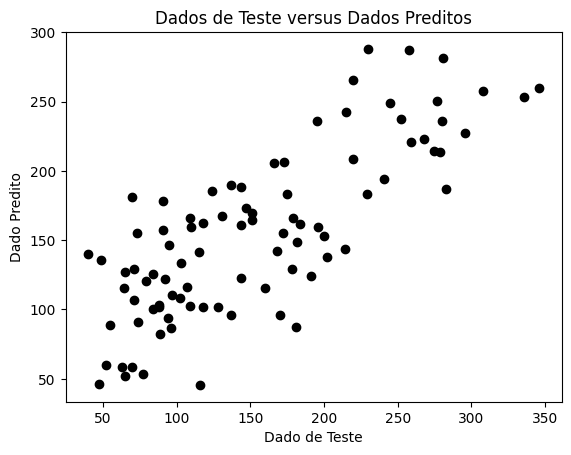

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline
predicao = regressor.predict(X_teste)
plt.scatter(y_teste, predicao, color='k')
plt.xlabel('Dado de Teste')
plt.ylabel('Dado Predito')
plt.title('Dados de Teste versus Dados Preditos')
plt.show()

In [10]:
import numpy as np
from sklearn import metrics
print ('Erro Médio Absoluto', metrics.mean_absolute_error(y_teste, predicao))
print ('Erro Quadrático Médio', metrics.mean_squared_error(y_teste, predicao))
print ('Raiz do Erro Quadrático Médio', np.sqrt(metrics.mean_squared_error(y_teste, predicao)))

Erro Médio Absoluto 39.22466065716576
Erro Quadrático Médio 2228.0908310594646
Raiz do Erro Quadrático Médio 47.20265703389445


In [11]:
# para obter os parâmetros da equação regressora
print(regressor.intercept_)
print(regressor.coef_)

-307.57104546505445
[ 1.40608997e-01 -2.56128390e+01  5.08771783e+00  1.19293496e+00
 -1.08819176e+00  8.03227722e-01  4.24108443e-02  4.53744471e+00
  6.51304992e+01  3.71060693e-01]
